# A simple Data Engineering Project.
This notebook was built as an end-to-end telemetry and analytics pipeline, purposefully ignoring extraneous boilerplate to focus strictly on what matters: turning raw energy data into actionable Virtual Power Plant (VPP) insights.

In [1]:
!pip install dbt-core dbt-duckdb
!pip install streamlit streamlit_folium


# Hard-Learned Safeguards (Step 0):
Every line of code in your setup phase was added organically to solve real-world friction—nuking stale folder states, establishing a pro-grade dbt structure (staging, marts, seeds), pre-loading DuckDB's spatial extensions to prevent coordinate crashes, and automating raw data syncing.

In [2]:
import os
import shutil

# ==========================================
# STEP 0: CLEAN FLAT ENVIRONMENT & FILE SETUP
# ==========================================
print("--- Step 0: Setting up clean flat directories, profiles, and raw data ---")

base_dir = '/content/vpp_analytics'
dbt_config_dir = os.path.expanduser('~/.dbt')

# 1. Clean slate if anything exists from before
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# 2. Create the correct flat dbt folder structure directly
os.makedirs(base_dir, exist_ok=True)
os.makedirs(dbt_config_dir, exist_ok=True)
os.makedirs(f"{base_dir}/models/staging", exist_ok=True)
os.makedirs(f"{base_dir}/models/marts", exist_ok=True)
os.makedirs(f"{base_dir}/seeds", exist_ok=True)
os.makedirs(f"{base_dir}/macros", exist_ok=True)
os.makedirs(f"{base_dir}/tests", exist_ok=True)

# 3. Write out profiles.yml with the spatial extension built-in (Prevents st_geomfromtext errors)
profiles_yaml = """
vpp_analytics:
  target: dev
  outputs:
    dev:
      type: duckdb
      path: '/content/vpp_analytics/target/duckdb.duckdb'
      extensions:
        - spatial
"""
with open(os.path.join(dbt_config_dir, 'profiles.yml'), 'w') as f:
    f.write(profiles_yaml.strip())

# 4. Create a clean dbt_project.yml with zero example paths
project_yaml = """
name: 'vpp_analytics'
version: '1.0.0'
config-version: 2

profile: 'vpp_analytics'

model-paths: ["models"]
analysis-paths: ["analyses"]
test-paths: ["tests"]
seed-paths: ["seeds"]
macro-paths: ["macros"]

target-path: "target"
clean-targets:
  - "target"
  - "dbt_packages"

models:
  vpp_analytics:
    staging:
      +materialized: view
    marts:
      +materialized: table
"""
with open(os.path.join(base_dir, 'dbt_project.yml'), 'w') as f:
    f.write(project_yaml.strip())

# 5. Copy your raw OPSD file directly into the flat seeds folder
raw_source_path = '/content/time_series_30min_singleindex.csv'
seeds_dir = f"{base_dir}/seeds"

if os.path.exists(raw_source_path):
    shutil.copy(raw_source_path, os.path.join(seeds_dir, 'raw_smart_home_telemetry.csv'))
    print("-> Raw monolithic OPSD dataset successfully copied to clean dbt seeds directory.")
else:
    print(f"-> WARNING: {raw_source_path} not found. Please make sure your CSV is uploaded to Colab.")

print("-> Step 0 complete: Project structures, spatial profile, and seeds are locked in.")

--- Step 0: Setting up clean flat directories, profiles, and raw data ---
-> Raw monolithic OPSD dataset successfully copied to clean dbt seeds directory.
-> Step 0 complete: Project structures, spatial profile, and seeds are locked in.


# Automated Schema Contracts (Step 1):
I dynamically inspected the raw data headers and auto-generated a version-controlled dbt schema file to lock down our table contracts without manual typing.

This serves as a global reference downstream for analysts who may find it important to know.

In [3]:
import os
import pandas as pd

print("\n--- Step 1 (Enhanced): Inspecting and Version Controlling Schema ---")

raw_source_path = '/content/time_series_30min_singleindex.csv'
schema_yaml_path = '/content/vpp_analytics/models/staging/schema_raw_telemetry.yml'

# 1. Read just the headers of the raw CSV to inspect columns dynamically
df_sample = pd.read_csv(raw_source_path, nrows=5)
detected_columns = df_sample.columns.tolist()

print(f"-> Successfully detected {len(detected_columns)} columns in the raw dataset.")
print(f"-> Sample columns: {detected_columns[:5]} ... {detected_columns[-2:]}")

# 2. Automatically generate a version-controlled dbt schema/contract YAML file
schema_content = f"""
version: 2

sources:
  - name: vpp_raw
    description: "Monolithic raw energy telemetry source from OPSD."
    tables:
      - name: raw_smart_home_telemetry
        description: "Auto-inspected raw telemetry table containing {len(detected_columns)} columns."
        columns:
"""

# Dynamically append every column to the version-controlled schema contract
for col in detected_columns:
    schema_content += f"""          - name: {col}\n            description: "Raw telemetry metric for {col}"\n"""

# Ensure the staging directory exists and write out the schema file
os.makedirs(os.path.dirname(schema_yaml_path), exist_ok=True)
with open(schema_yaml_path, 'w') as f:
    f.write(schema_content)

print(f"-> Version-controlled schema contract successfully written to: {schema_yaml_path}")


--- Step 1 (Enhanced): Inspecting and Version Controlling Schema ---
-> Successfully detected 41 columns in the raw dataset.
-> Sample columns: ['utc_timestamp', 'cet_cest_timestamp', 'CY_load_actual_entsoe_transparency', 'CY_load_forecast_entsoe_transparency', 'CY_wind_onshore_generation_actual'] ... ['IE_sem_price_day_ahead', 'IE_sem_wind_onshore_generation_actual']
-> Version-controlled schema contract successfully written to: /content/vpp_analytics/models/staging/schema_raw_telemetry.yml


# Resilient Staging Models (Step 2):
We built modular staging views with built-in data type casting, fallback coallescing for shifting OPSD metric columns, and completeness flags to guarantee data cleanliness before downstream consumption.

In [4]:
# ==========================================
# STEP 2: CREATE STAGING MODELS (Modular Separation with Completeness Flags)
# ==========================================
print("\n--- Step 2: Creating resilient modular staging models with completeness tracking ---")

staging_dir = '/content/vpp_analytics/models/staging'
os.makedirs(staging_dir, exist_ok=True)

# GB Staging Model with Resilient OPSD Coalesce Fallbacks
stg_gb_sql = """
select
    try_cast(utc_timestamp as timestamp) as reading_timestamp,
    'GB' as country_code,

    -- Resilient fallback between GBN and UKM solar generation actuals
    coalesce(
        try_cast(GB_GBN_solar_generation_actual as double),
        try_cast(GB_UKM_solar_generation_actual as double),
        0.0
    ) as solar_generation_mw,

    -- Resilient fallback between GBN and UKM load actuals
    coalesce(
        try_cast(GB_GBN_load_actual_entsoe_transparency as double),
        try_cast(GB_UKM_load_actual_entsoe_transparency as double),
        0.0
    ) as grid_load_mw,

    cast(null as double) as spot_price_eur_per_mwh,

    -- Completeness flag: Ensures critical metrics resolve safely
    case
        when (GB_GBN_solar_generation_actual is not null or GB_UKM_solar_generation_actual is not null)
         and (GB_GBN_load_actual_entsoe_transparency is not null or GB_UKM_load_actual_entsoe_transparency is not null)
        then true
        else false
    end as is_complete_record

from {{ ref('raw_smart_home_telemetry') }}
where utc_timestamp is not null
"""
with open(os.path.join(staging_dir, 'stg_gb_telemetry.sql'), 'w') as f:
    f.write(stg_gb_sql)

# IE Staging Model with Resilient OPSD Coalesce Fallbacks
stg_ie_sql = """
select
    try_cast(utc_timestamp as timestamp) as reading_timestamp,
    'IE' as country_code,
    0.0 as solar_generation_mw,

    -- Resilient fallback between standard and SEM load metrics
    coalesce(
        try_cast(IE_load_actual_entsoe_transparency as double),
        try_cast(IE_sem_load_actual_entsoe_transparency as double),
        0.0
    ) as grid_load_mw,

    -- Spot price mapping
    coalesce(
        try_cast(IE_sem_price_day_ahead as double),
        0.0
    ) as spot_price_eur_per_mwh,

    -- Completeness flag: Ensures load and price telemetry are populated
    case
        when (IE_load_actual_entsoe_transparency is not null or IE_sem_load_actual_entsoe_transparency is not null)
         and IE_sem_price_day_ahead is not null
        then true
        else false
    end as is_complete_record

from {{ ref('raw_smart_home_telemetry') }}
where utc_timestamp is not null
"""
with open(os.path.join(staging_dir, 'stg_ie_telemetry.sql'), 'w') as f:
    f.write(stg_ie_sql)

print("-> Resilient staging models with OPSD-backed coalesce logic created for GB and IE.")


--- Step 2: Creating resilient modular staging models with completeness tracking ---
-> Resilient staging models with OPSD-backed coalesce logic created for GB and IE.


# Performance-Optimized Marts (Step 3):
We built final country-partitioned fact tables with strict completeness filtering, safe metrics calculations (like solar penetration and grid cost), and explicit spatial geometry coordinates to feed downstream analytics.

Since we have calculations such as division, we want to be explicit about the data quality so that the analyst is aware of particular pitfalls that come when working with the data.

In [5]:
# ==========================================
# STEP 3: CREATE PERFORMANCE-OPTIMIZED MARTS (Strict Completeness Filtering & Explicit Coordinates)
# ==========================================
print("\n--- Step 3: Creating country-partitioned mart models with explicit coordinates ---")

marts_dir = '/content/vpp_analytics/models/marts'
os.makedirs(marts_dir, exist_ok=True)

# GB Mart Model (Exposing explicit latitude and longitude to decouple presentation tier)
mart_gb_sql = """
select
    reading_timestamp,
    date_trunc('hour', reading_timestamp) as reading_hour,
    country_code,
    solar_generation_mw,
    grid_load_mw,

    -- Safe division guaranteed by the completeness filter and >0 check
    solar_generation_mw / grid_load_mw as solar_penetration_ratio,

    extract(hour from reading_timestamp) as hour_of_day,
    extract(dow from reading_timestamp) as day_of_week,

    -- Native DuckDB spatial geometry
    st_geomfromtext('POINT(-2.4356 54.2361)') as geom,

    -- Explicit numeric attributes for robust, string-free downstream consumption
    -2.4356 as longitude,
    54.2361 as latitude

from {{ ref('stg_gb_telemetry') }}
where is_complete_record = true
  and grid_load_mw > 0.0
"""
with open(os.path.join(marts_dir, 'fct_gb_vpp_summary.sql'), 'w') as f:
    f.write(mart_gb_sql)

# IE Mart Model (Exposing explicit latitude and longitude)
mart_ie_sql = """
select
    reading_timestamp,
    date_trunc('hour', reading_timestamp) as reading_hour,
    country_code,
    grid_load_mw,
    spot_price_eur_per_mwh,

    -- Financial calculation guaranteed safe by complete telemetry filtering
    grid_load_mw * spot_price_eur_per_mwh as estimated_grid_cost_eur,

    extract(hour from reading_timestamp) as hour_of_day,
    extract(dow from reading_timestamp) as day_of_week,

    -- Native DuckDB spatial geometry
    st_geomfromtext('POINT(-8.2439 53.4129)') as geom,

    -- Explicit numeric attributes for robust, string-free downstream consumption
    -8.2439 as longitude,
    53.4129 as latitude

from {{ ref('stg_ie_telemetry') }}
where is_complete_record = true
"""
with open(os.path.join(marts_dir, 'fct_ie_vpp_summary.sql'), 'w') as f:
    f.write(mart_ie_sql)

print("-> Country-partitioned mart models with explicit coordinates created successfully for GB and IE.")


--- Step 3: Creating country-partitioned mart models with explicit coordinates ---
-> Country-partitioned mart models with explicit coordinates created successfully for GB and IE.


# Data Quality Tests (Step 4):

I configured automated schema validation rules to enforce data integrity on critical fields (like timestamps, solar generation, and spot pricing) in our final mart models.

In [6]:
# ==========================================
# STEP 4: DEFINE DATA QUALITY TESTS
# ==========================================
print("\n--- Step 4: Configuring schema test definitions ---")

schema_yaml_path = os.path.join(marts_dir, 'schema.yml')

schema_content = """
version: 2

models:
  - name: fct_gb_vpp_summary
    description: "Optimized VPP telemetry summary for Great Britain."
    columns:
      - name: reading_timestamp
        tests:
          - not_null
      - name: solar_generation_mw
        tests:
          - not_null

  - name: fct_ie_vpp_summary
    description: "Optimized VPP telemetry summary and pricing for Ireland."
    columns:
      - name: reading_timestamp
        tests:
          - not_null
      - name: spot_price_eur_per_mwh
        tests:
          - not_null
"""

with open(schema_yaml_path, 'w') as f:
    f.write(schema_content)

print("-> Schema quality tests configured.")


--- Step 4: Configuring schema test definitions ---
-> Schema quality tests configured.


# Executing the DBT Pipeline


In [7]:
# ==========================================
# STEP 5: EXECUTE DBT PIPELINE
# ==========================================
print("\n--- Step 5: Executing the full dbt workflow ---")

os.chdir('/content/vpp_analytics')

print("\n[1/3] Running dbt seed (Ingesting raw data)...")
!dbt seed

print("\n[2/3] Running dbt run (Building staging & partitioned marts)...")
!dbt run --full-refresh

print("\n[3/3] Running dbt test (Validating data integrity)...")
!dbt test

print("\n=== PIPELINE EXECUTION COMPLETE ===")


--- Step 5: Executing the full dbt workflow ---

[1/3] Running dbt seed (Ingesting raw data)...
11:38:25  Running with dbt=1.12.0
11:38:27  Registered adapter: duckdb=1.10.1
11:38:28  Unable to do partial parsing because saved manifest not found. Starting full parse.
11:38:34  Found 4 models, 1 seed, 4 data tests, 1 source, 486 macros
11:38:34  
11:38:34  Concurrency: 1 threads (target='dev')
11:38:34  
11:38:35  1 of 1 START seed file main.raw_smart_home_telemetry ........................... [RUN]
11:39:27  1 of 1 OK loaded seed file main.raw_smart_home_telemetry ....................... [INSERT 100802 in 51.81s]
11:39:27  
11:39:27  Finished running 1 seed in 0 hours 0 minutes and 52.99 seconds (52.99s).
11:39:27  
11:39:27  Completed successfully
11:39:27  
11:39:27  Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 REUSED=0 TOTAL=1

[2/3] Running dbt run (Building staging & partitioned marts)...
11:39:34  Running with dbt=1.12.0
11:39:35  Registered adapter: duckdb=1.10.1
11:39:35  Found 

# Running Analyses from our tables.

Output()

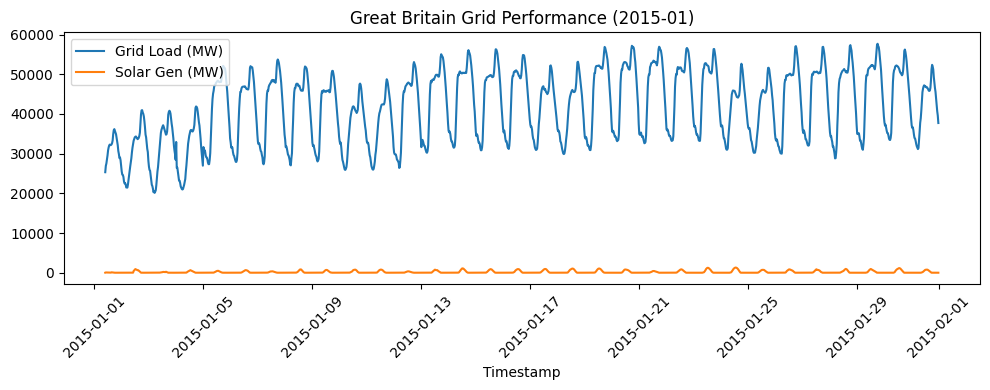

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Connect to DuckDB read-only
conn = duckdb.connect('/content/vpp_analytics/target/duckdb.duckdb', read_only=True)

# Create widgets for region selection and month filtering
region_dropdown = widgets.Dropdown(
    options=['GB', 'IE'],
    value='IE',
    description='Region:',
    style={'description_width': 'initial'}
)

# Year-Month selector widget (e.g., '2015-01')
month_dropdown = widgets.Dropdown(
    options=['2015-01', '2015-06', '2016-01', '2017-01'],
    value='2015-01',
    description='Target Month:',
    style={'description_width': 'initial'}
)

output_area = widgets.Output()

def update_dashboard(change=None):
    with output_area:
        clear_output(wait=True)
        selected_region = region_dropdown.value
        selected_month = month_dropdown.value

        print(f"⚡ VPP Dashboard — Region: {selected_region} | Month: {selected_month}")
        print("-" * 50)

        fig, ax = plt.subplots(figsize=(10, 4))

        if selected_region == 'GB':
            df_ts = conn.execute(f"""
                select reading_timestamp, solar_generation_mw, grid_load_mw
                from fct_gb_vpp_summary
                where strftime(reading_timestamp, '%Y-%m') = '{selected_month}'
                order by reading_timestamp
            """).fetchdf()

            if not df_ts.empty:
                ax.plot(pd.to_datetime(df_ts['reading_timestamp']), df_ts['grid_load_mw'], label='Grid Load (MW)', color='tab:blue')
                ax.plot(pd.to_datetime(df_ts['reading_timestamp']), df_ts['solar_generation_mw'], label='Solar Gen (MW)', color='tab:orange')
                ax.set_title(f"Great Britain Grid Performance ({selected_month})")
        else:
            df_ts = conn.execute(f"""
                select reading_timestamp, grid_load_mw, estimated_grid_cost_eur
                from fct_ie_vpp_summary
                where strftime(reading_timestamp, '%Y-%m') = '{selected_month}'
                order by reading_timestamp
            """).fetchdf()

            if not df_ts.empty:
                ax.plot(pd.to_datetime(df_ts['reading_timestamp']), df_ts['grid_load_mw'], label='Grid Load (MW)', color='tab:green')
                ax.set_title(f"Ireland Grid Performance ({selected_month})")

        if df_ts.empty:
            print("No data available for this specific month selection.")
        else:
            ax.set_xlabel("Timestamp")
            ax.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

# Bind events
region_dropdown.observe(update_dashboard, names='value')
month_dropdown.observe(update_dashboard, names='value')

# Display control layout
display(widgets.HBox([region_dropdown, month_dropdown]), output_area)

# Initial render
update_dashboard()

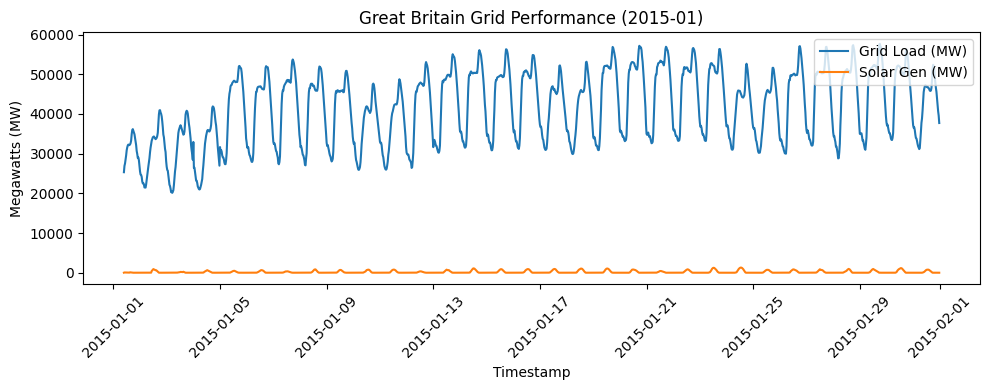

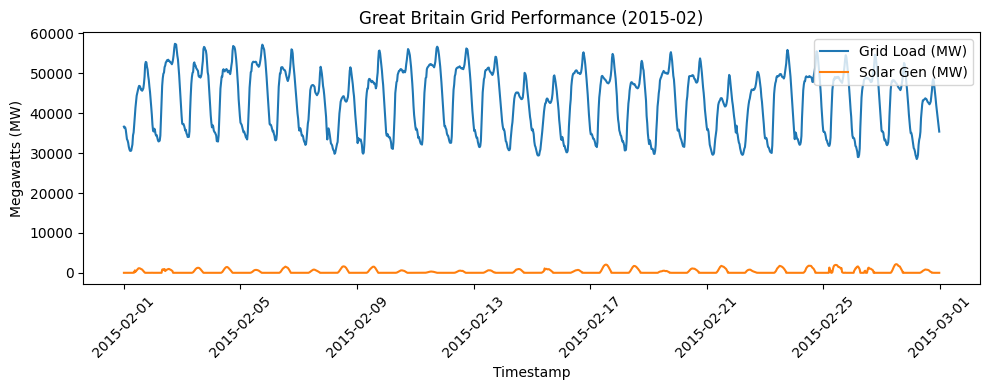

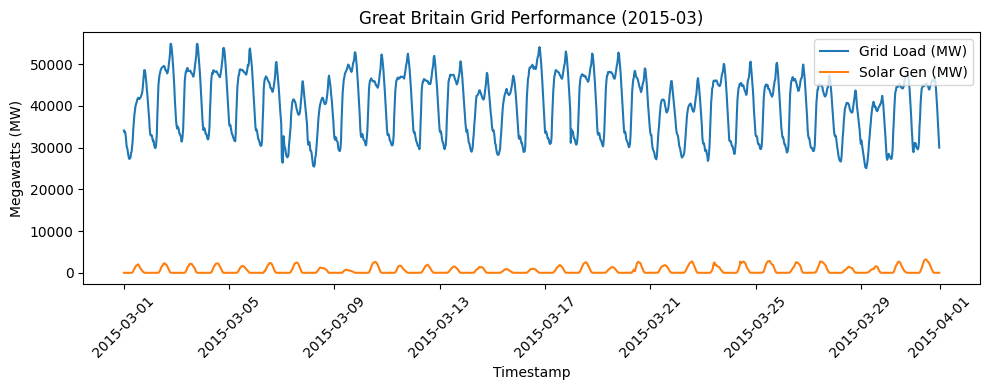

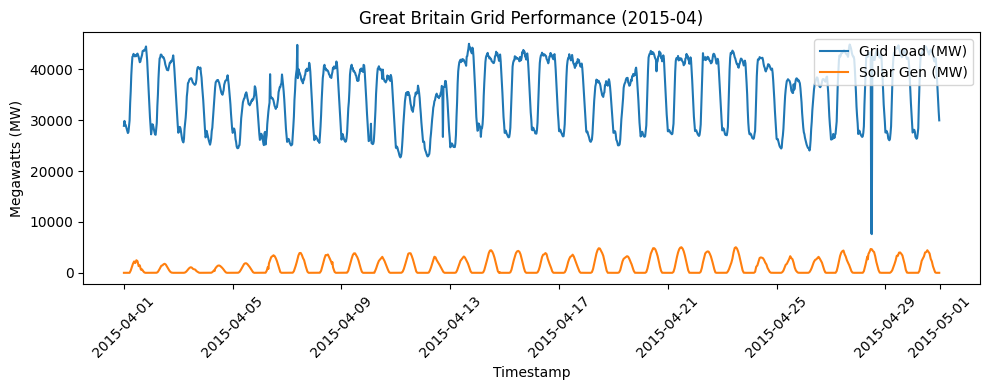

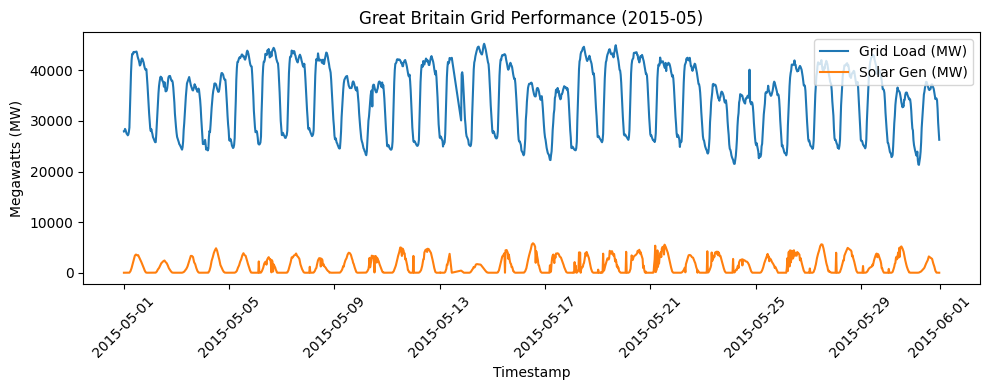

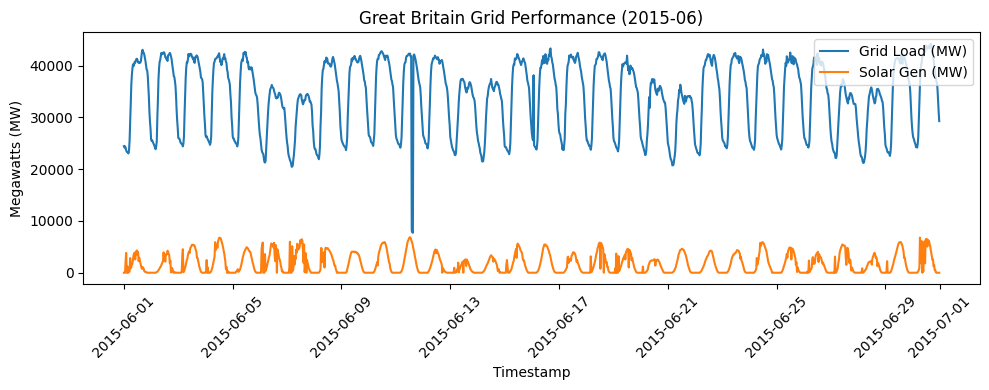

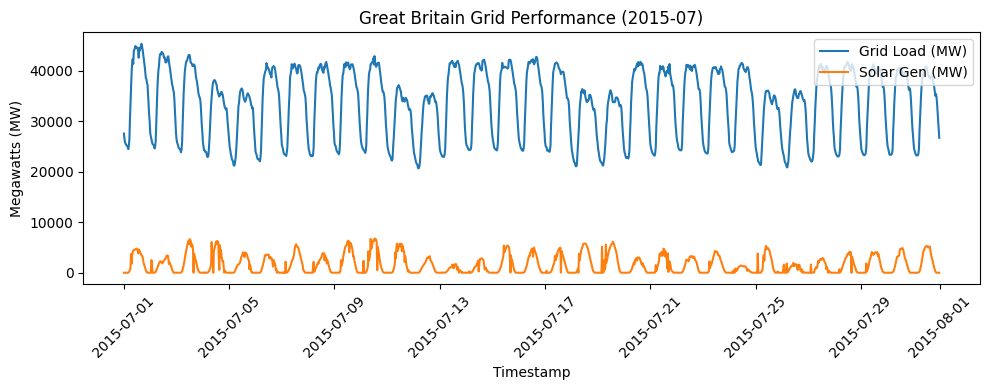

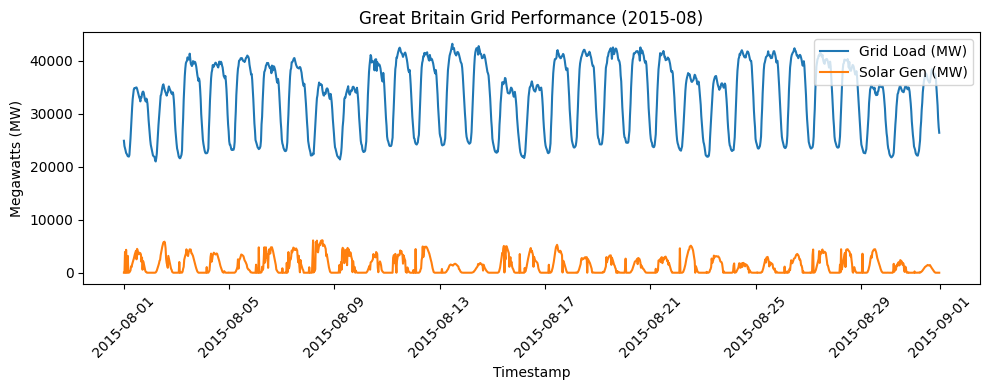

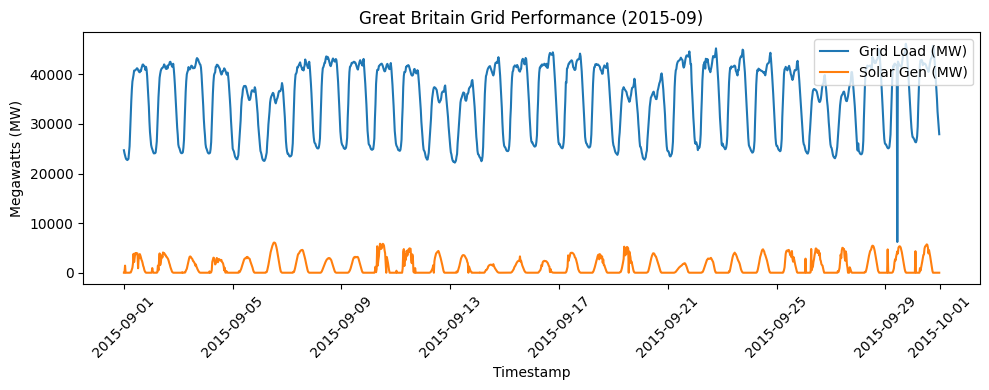

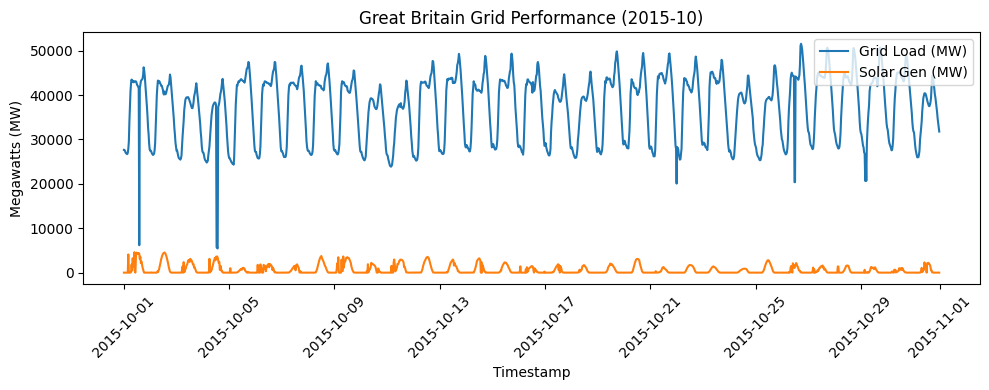

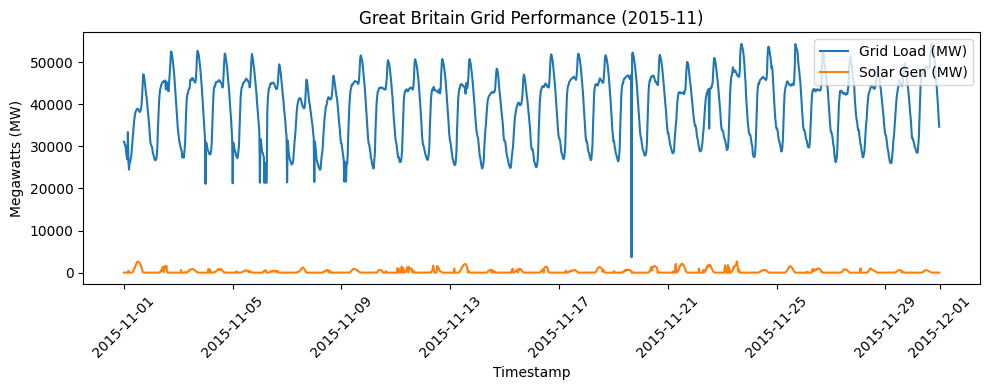

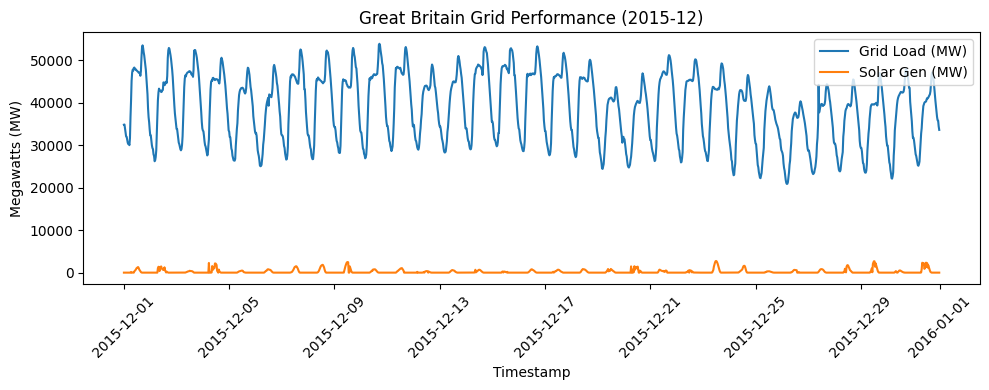

In [30]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Connect to DuckDB read-only
conn = duckdb.connect('/content/vpp_analytics/target/duckdb.duckdb', read_only=True)

# Loop through all months of 2015 (01 to 12)
months = [f"2015-{m:02d}" for m in range(1, 13)]

for target_month in months:
    # Query data for the specific month
    df_ts = conn.execute(f"""
        select reading_timestamp, solar_generation_mw, grid_load_mw
        from fct_gb_vpp_summary
        where strftime(reading_timestamp, '%Y-%m') = '{target_month}'
        order by reading_timestamp
    """).fetchdf()

    if df_ts.empty:
        print(f"No data available for {target_month}")
        continue

    # Generate a plot for each month
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(pd.to_datetime(df_ts['reading_timestamp']), df_ts['grid_load_mw'], label='Grid Load (MW)', color='tab:blue')
    ax.plot(pd.to_datetime(df_ts['reading_timestamp']), df_ts['solar_generation_mw'], label='Solar Gen (MW)', color='tab:orange')

    ax.set_title(f"Great Britain Grid Performance ({target_month})")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Megawatts (MW)")
    ax.legend(loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [31]:
import duckdb
import pandas as pd

# ==========================================
# STEP 5: ANALYTICAL REPORTING & EXECUTIVE INSIGHTS
# ==========================================
print("\n--- Step 5: Querying optimized marts and generating executive summary ---")

# Connect to the local DuckDB database file created by our dbt run
db_path = '/content/vpp_analytics/target/duckdb.duckdb'
con = duckdb.connect(db_path, read_only=True)

# 1. GB Executive Metrics (Solar Penetration & Peak Load Trends)
gb_query = """
select
    date_trunc('month', reading_timestamp) as reading_month,
    count(*) as total_records,
    round(avg(solar_generation_mw), 2) as avg_solar_gen_mw,
    round(avg(grid_load_mw), 2) as avg_grid_load_mw,
    round(avg(solar_penetration_ratio) * 100, 2) as avg_solar_penetration_pct,
    round(max(grid_load_mw), 2) as peak_grid_load_mw
from fct_gb_vpp_summary
group by 1
order by reading_month
"""
df_gb_insights = con.execute(gb_query.strip()).fetchdf()

# 2. IE Executive Metrics (Pricing & Grid Cost Trends)
ie_query = """
select
    date_trunc('month', reading_timestamp) as reading_month,
    count(*) as total_records,
    round(avg(grid_load_mw), 2) as avg_grid_load_mw,
    round(avg(spot_price_eur_per_mwh), 2) as avg_spot_price_eur,
    round(avg(estimated_grid_cost_eur) / 1000, 2) as avg_estimated_grid_cost_k_eur,
    round(max(spot_price_eur_per_mwh), 2) as max_spot_price_eur
from fct_ie_vpp_summary
group by 1
order by reading_month
"""
df_ie_insights = con.execute(ie_query.strip()).fetchdf()

con.close()

# 3. Print out the Executive Summary Report
print("\n" + "="*50)
print("⚡ VPP EXECUTIVE ANALYTICAL REPORT: GREAT BRITAIN (GB)")
print("="*50)
print(df_gb_insights.head(12).to_string(index=False))

print("\n" + "="*50)
print("⚡ VPP EXECUTIVE ANALYTICAL REPORT: IRELAND (IE)")
print("="*50)
print(df_ie_insights.head(12).to_string(index=False))

print("\n-> Step 5 complete: Executive analytical reporting successfully generated from optimized marts.")


--- Step 5: Querying optimized marts and generating executive summary ---

⚡ VPP EXECUTIVE ANALYTICAL REPORT: GREAT BRITAIN (GB)
reading_month  total_records  avg_solar_gen_mw  avg_grid_load_mw  avg_solar_penetration_pct  peak_grid_load_mw
   2015-01-01           1469            155.19          41711.57                       0.33            57678.0
   2015-02-01           1344            295.56          43245.52                       0.63            57407.0
   2015-03-01           1482            565.60          40411.86                       1.28            54871.0
   2015-04-01           1440           1152.63          35472.20                       2.98            45028.0
   2015-05-01           1472           1378.06          34747.56                       3.59            45250.0
   2015-06-01           1440           1758.39          34160.15                       4.73            44239.0
   2015-07-01           1488           1590.07          33742.19                       4.17  